In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

# 1.Data Collection

In [57]:
now =datetime.now()

In [58]:
start=datetime(now.year-10,now.month,now.day)
end=now
ticker='AAPL'
df = yf.download(ticker, start=start, end=end)
df


C:\Users\Dell\AppData\Local\Temp\ipykernel_15952\2872205352.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-09-18,25.495117,25.686135,25.140052,25.216458,297141200
2015-09-21,25.890636,25.926593,25.542313,25.544559,200888000
2015-09-22,25.483883,25.659169,25.286123,25.479387,201384800
2015-09-23,25.690624,25.780515,25.461405,25.535563,143026800
2015-09-24,25.843439,25.955802,25.252412,25.450169,200878000
...,...,...,...,...,...
2025-09-11,230.029999,230.449997,226.649994,226.880005,50208600
2025-09-12,234.070007,234.509995,229.020004,229.220001,55824200


In [59]:
df.head()


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-09-18,25.495117,25.686135,25.140052,25.216458,297141200
2015-09-21,25.890636,25.926593,25.542313,25.544559,200888000
2015-09-22,25.483883,25.659169,25.286123,25.479387,201384800
2015-09-23,25.690624,25.780515,25.461405,25.535563,143026800
2015-09-24,25.843439,25.955802,25.252412,25.450169,200878000


In [60]:
type(df)

pandas.core.frame.DataFrame

In [61]:
df.shape

(2514, 5)

In [62]:
df.isna().sum()


Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [63]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2514.000000,2514.000000,2514.000000,2514.000000,2.514000e+03
mean,107.409085,108.482150,106.223006,107.306045,1.056276e+08
std,69.960473,70.641312,69.194378,69.885431,5.943125e+07
min,20.624046,20.927684,20.425432,20.546434,2.323470e+07
25%,40.375730,40.752689,40.061316,40.439102,6.505010e+07
50%,111.828506,112.902098,109.761464,111.541540,9.176630e+07
75%,168.423038,169.761942,166.958540,167.971469,1.295504e+08
max,258.103729,259.179926,256.718662,257.276679,5.334788e+08


In [64]:
df.dtypes

Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

In [65]:
df.reset_index()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2015-09-18,25.495117,25.686135,25.140052,25.216458,297141200
1,2015-09-21,25.890636,25.926593,25.542313,25.544559,200888000
2,2015-09-22,25.483883,25.659169,25.286123,25.479387,201384800
3,2015-09-23,25.690624,25.780515,25.461405,25.535563,143026800
4,2015-09-24,25.843439,25.955802,25.252412,25.450169,200878000
...,...,...,...,...,...,...
2509,2025-09-11,230.029999,230.449997,226.649994,226.880005,50208600
2510,2025-09-12,234.070007,234.509995,229.020004,229.220001,55824200
2511,2025-09-15,236.699997,238.190002,235.029999,237.000000,42699500


In [66]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-09-18,25.495117,25.686135,25.140052,25.216458,297141200
2015-09-21,25.890636,25.926593,25.542313,25.544559,200888000
2015-09-22,25.483883,25.659169,25.286123,25.479387,201384800
2015-09-23,25.690624,25.780515,25.461405,25.535563,143026800
2015-09-24,25.843439,25.955802,25.252412,25.450169,200878000


Text(0, 0.5, 'close price')

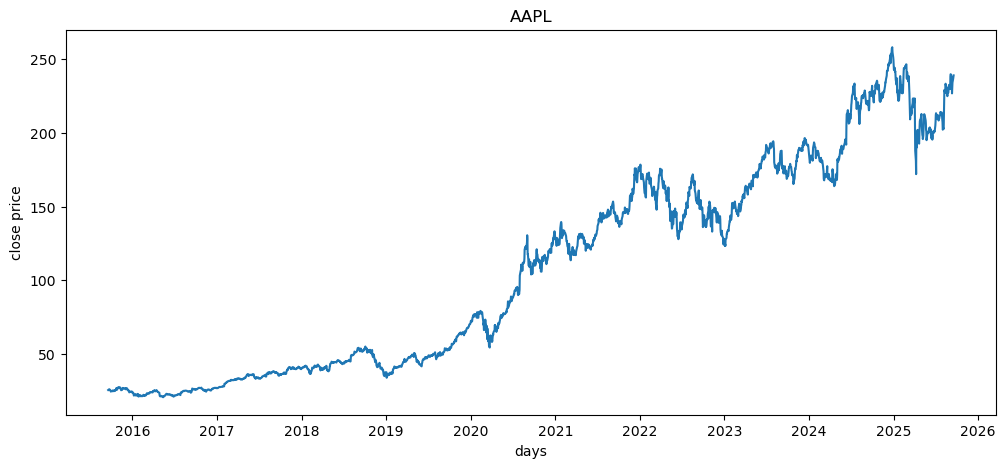

In [67]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.title(ticker)
plt.xlabel('days')
plt.ylabel('close price')

In [68]:
print(df.columns)


MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])


# 3.feature Engineering

In [69]:
#10,20,30,40,50,60,70,80,90,100
#MA of 5 days ==> null null null null 30

temp_df=[10,20,30,40,50,60,70,80,90,100]
print(sum(temp_df[2:7])/5)

50.0


In [70]:
df1=pd.DataFrame([10,20,30,40,50,60,70,80,90,100])
df1

,0
0,10
1,20
2,30
3,40
4,50
5,60
6,70
7,80
8,90
9,100


In [71]:
df1['MA_5']=df1.rolling(5).mean()
df1

,0,MA_5
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


### 100 Days Moving average

In [72]:
df['MA_100'] = df['Close'].rolling(100).mean()

df
df.head()

Price,Close,High,Low,Open,Volume,MA_100
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2015-09-18,25.495117,25.686135,25.140052,25.216458,297141200,NaN
2015-09-21,25.890636,25.926593,25.542313,25.544559,200888000,NaN
2015-09-22,25.483883,25.659169,25.286123,25.479387,201384800,NaN
2015-09-23,25.690624,25.780515,25.461405,25.535563,143026800,NaN
2015-09-24,25.843439,25.955802,25.252412,25.450169,200878000,NaN


[('AAPL', 'Open'), ('AAPL', 'High'), ('AAPL', 'Low'), ('AAPL', 'Close'), ('AAPL', 'Volume')]


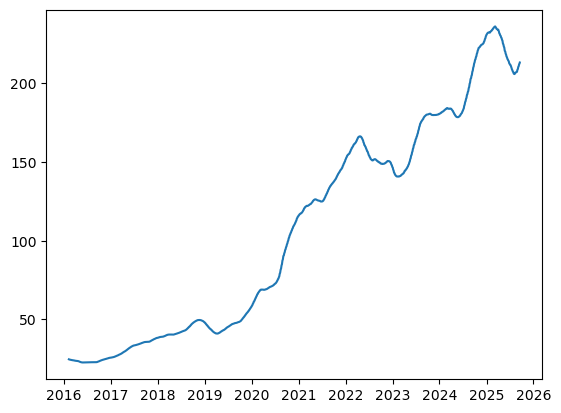

In [73]:
plt.plot(df['MA_100'])

Text(0, 0.5, 'close price')

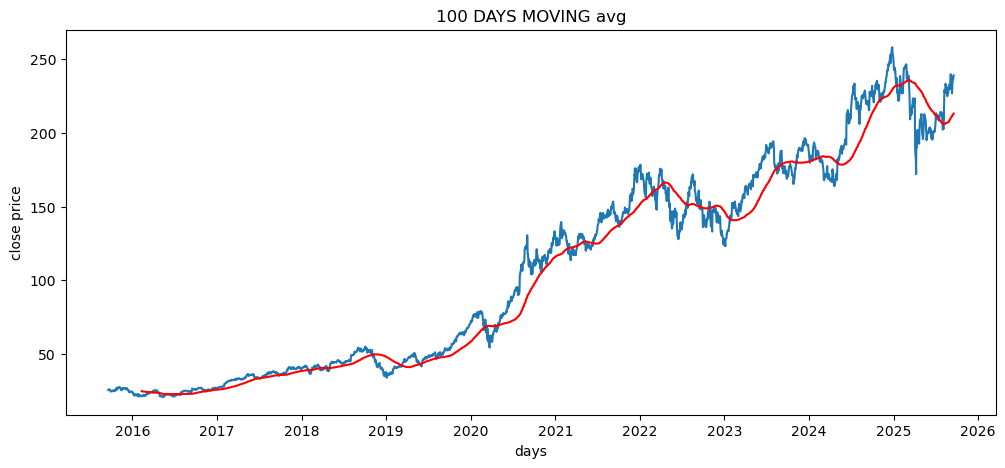

In [74]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.plot(df['MA_100'] , 'r')
plt.title('100 DAYS MOVING avg')
plt.xlabel('days')
plt.ylabel('close price')


### 200 days moving average

In [75]:


df['MA_200']=df.Close.rolling(200).mean()
df.head(203)


Price,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,
Date,,,,,,,
2015-09-18,25.495117,25.686135,25.140052,25.216458,297141200,NaN,NaN
2015-09-21,25.890636,25.926593,25.542313,25.544559,200888000,NaN,NaN
2015-09-22,25.483883,25.659169,25.286123,25.479387,201384800,NaN,NaN
2015-09-23,25.690624,25.780515,25.461405,25.535563,143026800,NaN,NaN
2015-09-24,25.843439,25.955802,25.252412,25.450169,200878000,NaN,NaN
...,...,...,...,...,...,...,...
2016-07-01,21.891087,22.023497,21.763243,21.799769,104106000,22.742147,NaN
2016-07-05,21.685614,21.779215,21.564618,21.776931,110820800,22.745093,23.730518


Text(0, 0.5, 'Price')

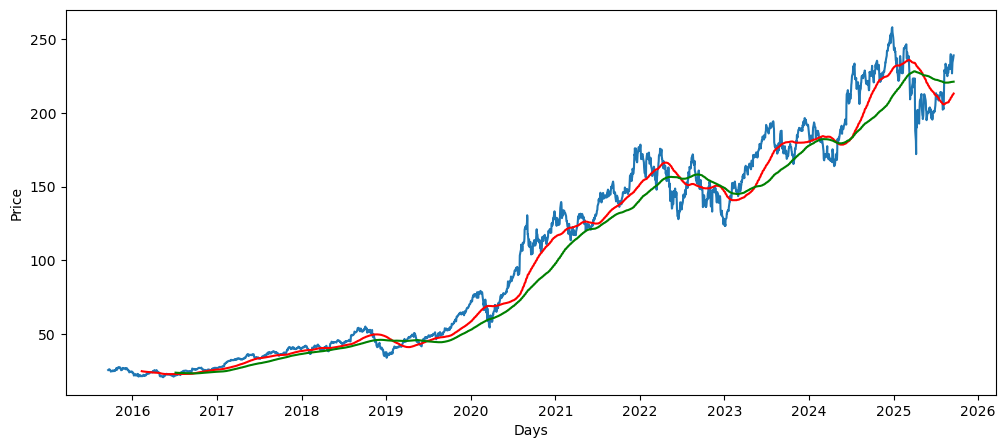

In [76]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'r')
plt.plot(df['MA_200'],'g')
plt.xlabel('Days')
plt.ylabel('Price')

### Calculating percent change in each trading section

In [77]:
df['percentage_changed']=df.Close.pct_change()
df [['Close', 'percentage_changed']]

Price,Close,percentage_changed
Ticker,AAPL,
Date,,
2015-09-18,25.495117,NaN
2015-09-21,25.890636,0.015514
2015-09-22,25.483883,-0.015710
2015-09-23,25.690624,0.008113
2015-09-24,25.843439,0.005948
...,...,...
2025-09-11,230.029999,0.014286
2025-09-12,234.070007,0.017563


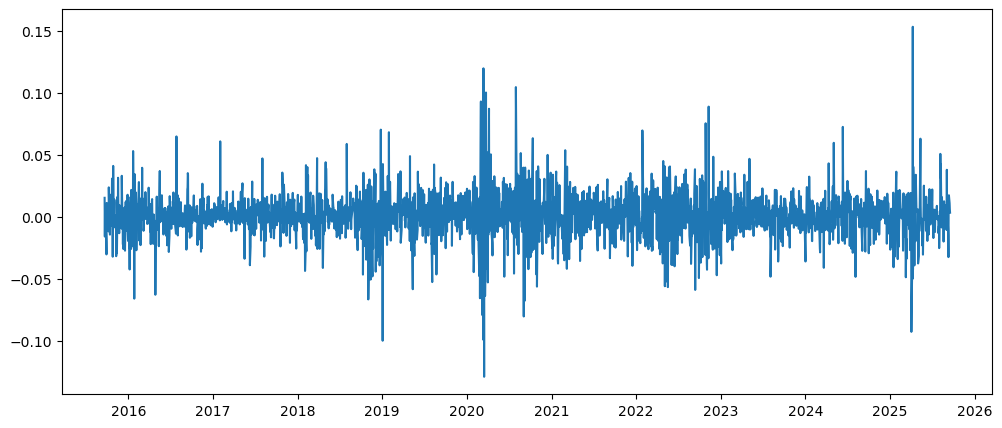

In [78]:
plt.figure(figsize=(12,5))
plt.plot(df['percentage_changed'])

# 4. Data Preprocessing

In [79]:
df.shape

(2514, 8)

#### splitting data into training & Testing datasets

In [80]:
data_training=pd.DataFrame(df.Close[0:int(len(df)*0.7)])
data_testing=pd.DataFrame(df.Close[int(len(df)*0.7):int(len(df))])
print(data_training)
print(data_testing)

Ticker            AAPL
Date                  
2015-09-18   25.495117
2015-09-21   25.890636
2015-09-22   25.483883
2015-09-23   25.690624
2015-09-24   25.843439
...                ...
2022-09-07  153.536392
2022-09-08  152.059662
2022-09-09  154.924469
2022-09-12  160.890259
2022-09-13  151.449310

[1759 rows x 1 columns]
Ticker            AAPL
Date                  
2022-09-14  152.896439
2022-09-15  150.002151
2022-09-16  148.358109
2022-09-19  152.079346
2022-09-20  154.461746
...                ...
2025-09-11  230.029999
2025-09-12  234.070007
2025-09-15  236.699997
2025-09-16  238.149994
2025-09-17  238.990005

[755 rows x 1 columns]


In [1]:
# scaling down the data btn 0 and 1


In [81]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))



In [82]:
data_training_arr=scaler.fit_transform(data_training)
data_training_arr

array([[0.0308649 ],
       [0.03337106],
       [0.03079372],
       ...,
       [0.85097699],
       [0.88877844],
       [0.82895711]], shape=(1759, 1))

In [83]:
type(data_training_arr)

numpy.ndarray

In [84]:
data_training_arr.shape

(1759, 1)

# 5.Sequence Creation

In [85]:
x_train=[]
y_train=[]

for i in range(100, data_training_arr.shape[0]):
    x_train.append(data_training_arr[i-100:i])
    y_train.append(data_training_arr[i,0])

    
x_train,y_train=np.array(x_train),np.array(y_train)
    


In [86]:
x_train

array([[[0.0308649 ],
        [0.03337106],
        [0.03079372],
        ...,
        [0.00592372],
        [0.005895  ],
        [0.00485975]],

       [[0.03337106],
        [0.03079372],
        [0.03210371],
        ...,
        [0.005895  ],
        [0.00485975],
        [0.00404023]],

       [[0.03079372],
        [0.03210371],
        [0.033072  ],
        ...,
        [0.00485975],
        [0.00404023],
        [0.00445717]],

       ...,

       [[0.89607189],
        [0.91056463],
        [0.90950709],
        ...,
        [0.83326125],
        [0.84218163],
        [0.83282452]],

       [[0.91056463],
        [0.90950709],
        [0.90446892],
        ...,
        [0.84218163],
        [0.83282452],
        [0.85097699]],

       [[0.90950709],
        [0.90446892],
        [0.87566975],
        ...,
        [0.83282452],
        [0.85097699],
        [0.88877844]]], shape=(1659, 100, 1))

In [13]:
y_train

array([0.00404019, 0.00445714, 0.00826732, ..., 0.85097689, 0.88877834,
       0.82895701], shape=(1659,))

In [87]:
x_train.ndim

3

In [88]:
y_train.ndim

1

# 6.Model Building

In [14]:
import tensorflow as tf

In [89]:
#ml model
from keras.models import Sequential
from keras.layers import Dense,LSTM, Input


In [90]:
model=Sequential()
model.add(Input(shape=(100,1)))
model.add(LSTM(units=128,activation='tanh',return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))

# 7 .Model Training

In [91]:
model.compile(optimizer='adam',loss='mean_squared_error')
model.fit(x_train,y_train,epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 15s 164ms/step - loss: 0.0106
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 162ms/step - loss: 5.1044e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 162ms/step - loss: 4.9288e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 162ms/step - loss: 5.1800e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 164ms/step - loss: 4.5345e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 163ms/step - loss: 4.3357e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 164ms/step - loss: 4.6410e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 252ms/step - loss: 6.0853e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 163ms/step - loss: 4.3121e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 165ms/step - loss: 4.1832e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 168ms/step - loss: 4.1171e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 170ms/step - loss: 3.3650e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 168ms/step - loss: 4.1025e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 172ms/step - loss: 4.2968e-04
Ep

In [92]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [93]:
#save the trained model
model.save('stock_prediction_model.keras')


In [94]:
data_testing

Ticker,AAPL
Date,
2022-09-14,152.896439
2022-09-15,150.002151
2022-09-16,148.358109
2022-09-19,152.079346
2022-09-20,154.461746
...,...
2025-09-11,230.029999
2025-09-12,234.070007
2025-09-15,236.699997


# 8. Preparing Test Data

In [101]:
past_100_days=data_training.tail(100)

In [102]:
past_100_days

Ticker,AAPL
Date,
2022-04-21,163.366516
2022-04-22,158.821457
2022-04-25,159.891479
2022-04-26,153.923035
2022-04-27,153.697266
...,...
2022-09-07,153.536392
2022-09-08,152.059662
2022-09-09,154.924469


In [103]:
final_df=pd.concat([past_100_days,data_testing],ignore_index=True)

In [104]:
final_df

Ticker,AAPL
0,163.366516
1,158.821457
2,159.891479
3,153.923035
4,153.697266
...,...
850,230.029999
851,234.070007
852,236.699997
853,238.149994


In [105]:
input_data=scaler.fit_transform(final_df)
input_data

array([[2.97318385e-01],
       [2.63606927e-01],
       [2.71543462e-01],
       [2.27274518e-01],
       [2.25599951e-01],
       [2.77077137e-01],
       [2.33463600e-01],
       [2.35720688e-01],
       [2.46787585e-01],
       [2.94405889e-01],
       [2.27056312e-01],
       [2.32451911e-01],
       [1.94388799e-01],
       [2.12253784e-01],
       [1.53846659e-01],
       [1.25117025e-01],
       [1.58294627e-01],
       [1.46846437e-01],
       [1.73826242e-01],
       [1.12429661e-01],
       [8.71267989e-02],
       [8.88770808e-02],
       [1.29127451e-01],
       [1.09075208e-01],
       [1.10241723e-01],
       [1.34012848e-01],
       [1.76742812e-01],
       [1.70909445e-01],
       [1.69961814e-01],
       [1.88191002e-01],
       [1.45679922e-01],
       [1.51221745e-01],
       [1.69961814e-01],
       [1.64492877e-01],
       [1.25700565e-01],
       [8.55228550e-02],
       [4.72409719e-02],
       [5.36576533e-02],
       [7.31266948e-02],
       [3.39698406e-02],


In [106]:
x_test=[]
y_test=[]
for i in range(100,input_data.shape[0]):
    x_test.append(input_data[i-100 : i])
    y_test.append(input_data[i,0])

In [107]:
x_test,y_test=np.array(x_test),np.array(y_test)

In [108]:
x_test

array([[[0.29731838],
        [0.26360693],
        [0.27154346],
        ...,
        [0.23470232],
        [0.27895157],
        [0.20892649]],

       [[0.26360693],
        [0.27154346],
        [0.22727452],
        ...,
        [0.27895157],
        [0.20892649],
        [0.21966008]],

       [[0.27154346],
        [0.22727452],
        [0.22559995],
        ...,
        [0.20892649],
        [0.21966008],
        [0.19819268]],

       ...,

       [[0.56348911],
        [0.59944849],
        [0.62734288],
        ...,
        [0.76774083],
        [0.79177249],
        [0.8217379 ]],

       [[0.59944849],
        [0.62734288],
        [0.634076  ],
        ...,
        [0.79177249],
        [0.8217379 ],
        [0.84124497]],

       [[0.62734288],
        [0.634076  ],
        [0.64043926],
        ...,
        [0.8217379 ],
        [0.84124497],
        [0.85199984]]], shape=(755, 100, 1))

In [109]:
x_test[1]

array([[0.26360693],
       [0.27154346],
       [0.22727452],
       [0.22559995],
       [0.27707714],
       [0.2334636 ],
       [0.23572069],
       [0.24678758],
       [0.29440589],
       [0.22705631],
       [0.23245191],
       [0.1943888 ],
       [0.21225378],
       [0.15384666],
       [0.12511702],
       [0.15829463],
       [0.14684644],
       [0.17382624],
       [0.11242966],
       [0.0871268 ],
       [0.08887708],
       [0.12912745],
       [0.10907521],
       [0.11024172],
       [0.13401285],
       [0.17674281],
       [0.17090944],
       [0.16996181],
       [0.188191  ],
       [0.14567992],
       [0.15122175],
       [0.16996181],
       [0.16449288],
       [0.12570057],
       [0.08552285],
       [0.04724097],
       [0.05365765],
       [0.07312669],
       [0.03396984],
       [0.04490749],
       [0.07633504],
       [0.07254327],
       [0.09383559],
       [0.11855446],
       [0.11855446],
       [0.08778311],
       [0.10083536],
       [0.082

# 9. Making Predictions

In [110]:
y_predicted=model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step


In [111]:
y_predicted

array([[0.23710826],
       [0.22908995],
       [0.21554595],
       [0.20097268],
       [0.20030428],
       [0.20993035],
       [0.21162362],
       [0.20822066],
       [0.19875844],
       [0.19154695],
       [0.18970194],
       [0.1854154 ],
       [0.16456306],
       [0.13643   ],
       [0.1244545 ],
       [0.12903549],
       [0.13835642],
       [0.14426793],
       [0.13515118],
       [0.12499405],
       [0.11429216],
       [0.1052285 ],
       [0.10939229],
       [0.10656694],
       [0.11116509],
       [0.11970417],
       [0.12716821],
       [0.13089007],
       [0.14099249],
       [0.154939  ],
       [0.17253752],
       [0.17831928],
       [0.16774489],
       [0.18176349],
       [0.19263302],
       [0.19258198],
       [0.17588583],
       [0.14598219],
       [0.12161283],
       [0.10757855],
       [0.10233355],
       [0.09181145],
       [0.10851811],
       [0.13610747],
       [0.15572636],
       [0.1705944 ],
       [0.17579505],
       [0.180

In [112]:
y_predicted=scaler.inverse_transform(y_predicted.reshape(-1,1)).flatten()

In [113]:
y_test=scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

In [114]:
y_predicted

array([155.24884 , 154.16779 , 152.34177 , 150.37697 , 150.28685 ,
       151.58466 , 151.81294 , 151.35414 , 150.07843 , 149.10616 ,
       148.8574  , 148.2795  , 145.46814 , 141.67516 , 140.06061 ,
       140.67822 , 141.93488 , 142.73189 , 141.50275 , 140.13335 ,
       138.69049 , 137.46849 , 138.02988 , 137.64896 , 138.26889 ,
       139.42015 , 140.42647 , 140.92825 , 142.29028 , 144.17058 ,
       146.54326 , 147.32277 , 145.89711 , 147.78712 , 149.25258 ,
       149.2457  , 146.99469 , 142.96301 , 139.67747 , 137.78534 ,
       137.0782  , 135.65958 , 137.912   , 141.63168 , 144.27675 ,
       146.28128 , 146.98244 , 147.63916 , 148.20865 , 147.4742  ,
       147.308   , 147.64539 , 147.07755 , 145.22134 , 142.67744 ,
       142.85223 , 143.89723 , 144.76236 , 144.93784 , 143.6787  ,
       141.78789 , 140.80603 , 140.24782 , 140.70381 , 141.64651 ,
       141.76506 , 139.57445 , 136.8038  , 134.08626 , 132.16335 ,
       131.90427 , 131.4067  , 130.87488 , 129.99033 , 128.181

In [112]:
y_test

array([6.85198596e+12, 6.72305660e+12, 6.64981946e+12, 6.81558761e+12,
       6.92171439e+12, 6.78225820e+12, 6.73928085e+12, 6.63797941e+12,
       6.65288975e+12, 6.69630417e+12, 6.61210585e+12, 6.28934133e+12,
       6.10164608e+12, 6.28802539e+12, 6.44809273e+12, 6.46124804e+12,
       6.41870910e+12, 6.18452913e+12, 6.19900242e+12, 6.13585164e+12,
       6.10778531e+12, 6.31170617e+12, 6.10953967e+12, 6.28627103e+12,
       6.34503558e+12, 6.34986023e+12, 6.32924703e+12, 6.49940142e+12,
       6.59500341e+12, 6.72174066e+12, 6.59061785e+12, 6.39108119e+12,
       6.87084344e+12, 6.76559350e+12, 6.64762600e+12, 6.40116756e+12,
       6.13146745e+12, 6.11960701e+12, 6.14332653e+12, 6.16880448e+12,
       5.96542332e+12, 6.49254305e+12, 6.61685710e+12, 6.55447984e+12,
       6.63179191e+12, 6.57688274e+12, 6.66166086e+12, 6.68670040e+12,
       6.54262008e+12, 6.63794134e+12, 6.67703614e+12, 6.54701311e+12,
       6.37613822e+12, 6.24216262e+12, 6.54349896e+12, 6.55579782e+12,
      

(140.0, 260.0)

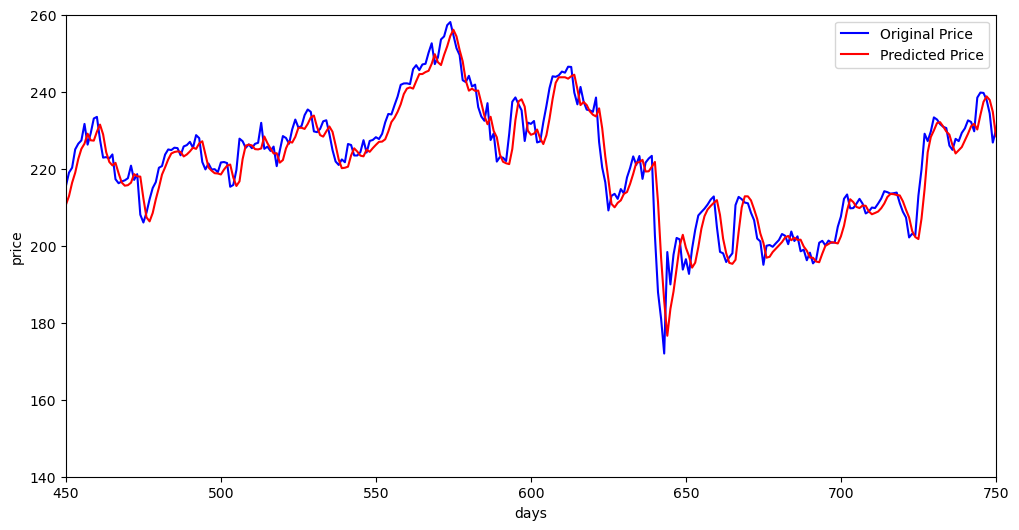

In [115]:
plt.figure(figsize=(12,6))
plt.plot(y_test,'b', label= 'Original Price')
plt.plot(y_predicted, 'r',label='Predicted Price')
plt.xlabel('days')
plt.ylabel('price')
plt.legend()
plt.xlim(450,750)
plt.ylim(140,260)

# 10. Model Evaluation

In [116]:
# mean squared error (MSE)
from sklearn.metrics import mean_squared_error,r2_score




In [117]:
mse=mean_squared_error(y_test,y_predicted)
print(f"Mean Squared Error (MSE) :{mse}")

Mean Squared Error (MSE) :15.434738055339688


In [118]:
#Root Mean Squared Error
rmse=np.sqrt(mse)
print(f"Root mean squared error (RMSE) : {rmse}")


Root mean squared error (RMSE) : 3.9287069189925186


In [119]:
# R-squared
r2=r2_score(y_test,y_predicted)
print(f"R-Squared : {r2}")

R-Squared : 0.9846067354114868
